# Notebook 4 - Speech Recognition

## 0. Importing modules and downloading Dataset

Setup all the imports.

In [2]:
import numpy as np
import kagglehub
import os
import tarfile
import urllib.request
import matplotlib.pyplot as plot
from numpy.random import seed

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import os
import numpy as np
import librosa
from tqdm import tqdm
from torch.nn import functional
from keras.utils import to_categorical

from torch import nn
import torch

I0000 00:00:1782374435.547871    6789 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782374435.612806    6789 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782374437.141016    6789 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782374437.141529    6789 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.

Instantiate the variables with the dataset name and the paths.

In [3]:
dataset = "speech_commands"
path = f"../data/{dataset}"
url = "https://storage.googleapis.com/download.tensorflow.org/data/speech_commands_v0.02.tar.gz"

Download and load the dataset.

In [4]:
print(f"Downloading dataset '{dataset}' and saving it on '{path}'...")

archive_path = "../data/speech_commands_v0.02.tar.gz"

print("Downloading...")
urllib.request.urlretrieve(url, archive_path)

print("Extracting...")
with tarfile.open(archive_path, "r:gz") as tar:
    tar.extractall(f"../data/{dataset}")

print("Dataset downloaded!")

Downloading...
Extracting...
Dataset downloaded!


In [42]:
WORDS = ["yes", "no", "go", "stop"]

X = []
y = []

for label, word in enumerate(WORDS):
    folder = os.path.join(path, word)
    for wav_file in os.listdir(folder):

        if not wav_file.endswith(".wav"):
            continue

        new_path = os.path.join(folder, wav_file)

        signal, sr = librosa.load(
            new_path,
            sr=16000
        )

        # Mel spectrogram
        mel = librosa.feature.melspectrogram(
            y=signal,
            sr=sr,
            n_mels=65,
            hop_length=256,
            n_fft=512
        )

        mel_db = librosa.power_to_db(
            mel,
            ref=np.max
        )

        # Force shape to (62,65)
        mel_db = mel_db.T

        if mel_db.shape[0] >= 62:
            mel_db = mel_db[:62, :]
        else:
            pad = np.zeros(
                (62 - mel_db.shape[0], 65)
            )
            mel_db = np.vstack([mel_db, pad])

        X.append(mel_db)
        y.append(label)

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(15737, 62, 65)
(15737,)


In [43]:
np.save(f"{path}/x.npy", X)
np.save(f"{path}/y.npy", y)

print("Saved X.npy and y.npy")

Saved X.npy and y.npy


In [3]:
x = np.load(f"{path}/x.npy")
y = np.load(f"{path}/y.npy")

In [4]:
labels = to_categorical(y, 4)
print(labels[0][0])
print(len(x))
data_train, data_test, labels_train, labels_test = train_test_split(x,y,test_size=0.2)

1.0
15737


(12589, 62, 65)


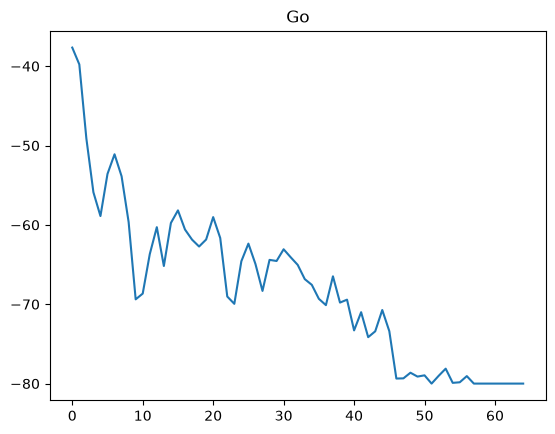

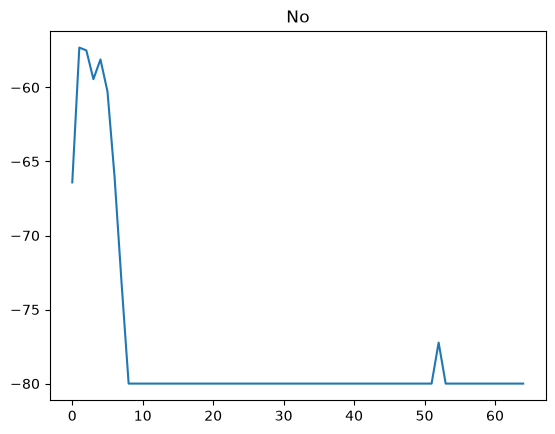

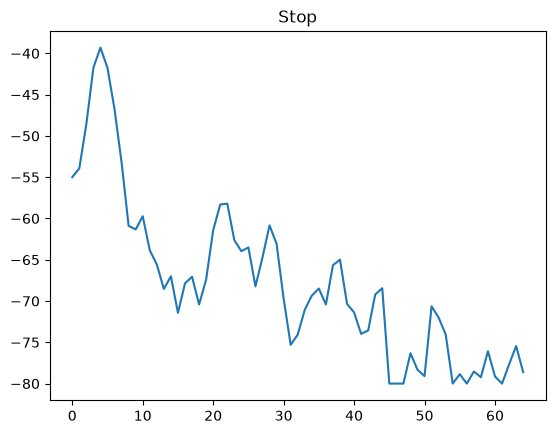

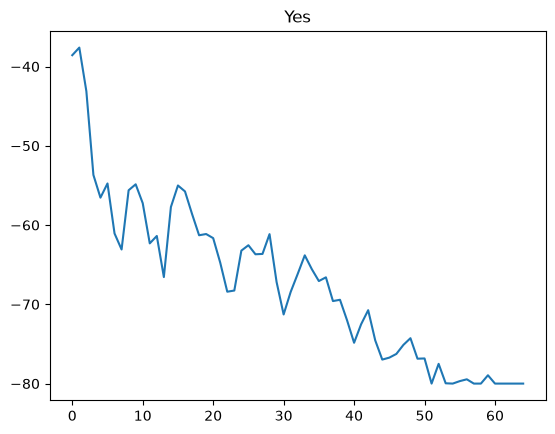

In [11]:
def to_string(l):
    if l[0] == 1.0:
        return "Go"
    elif l[1] == 1.0:
        return "No"
    elif l[2] == 1.0:
        return "Stop"
    elif l[3] == 1.0:
        return "Yes"

print(data_train.shape)
indexes = []
nums = []
num = 0

for i in labels:
    if to_string(i) not in nums:
        indexes.append(num)
        nums.append(to_string(i))
    num += 1

for n in indexes:
    plot.title(to_string(labels[n]))
    plot.plot(x[n][0])
    plot.show()

## 2. Training models and collecting data

In [50]:
dtra, dtrb, dtrc = data_train.shape
dtea, dteb, dtec = data_test.shape

reg = RandomForestClassifier().fit(data_train.reshape((dtra,dtrb*dtrc)), labels_train)

In [51]:
print("Accuracy on training data: {}".format(reg.score(data_train.reshape((dtra,dtrb*dtrc)), labels_train)))
print("Accuracy on test data: {}".format(reg.score(data_test.reshape((dtea,dteb*dtec)), labels_test)))

Accuracy on training data: 1.0
Accuracy on test data: 0.8742058449809402


## 3. Training a Neural Netowork

In [5]:
from torch.utils.data import DataLoader, TensorDataset

def train(net, train_values, train_labels, test_values, test_labels, num_epochs):
    x_train = torch.FloatTensor(train_values)
    x_test  = torch.FloatTensor(test_values)
    y_train = torch.LongTensor(train_labels)
    y_test  = torch.LongTensor(test_labels)

    # Wrap in DataLoader for batching
    train_loader = DataLoader(TensorDataset(x_train, y_train), batch_size=32, shuffle=True)
    test_loader  = DataLoader(TensorDataset(x_test,  y_test),  batch_size=32)

    # Setup
    device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(net.parameters(), lr=1e-4)

    # Training loop
    for epoch in range(num_epochs):
        net.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            loss = criterion(net(X_batch), y_batch)
            loss.backward()
            optimizer.step()

        net.eval()
        correct = total = 0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                preds = net(X_batch).argmax(dim=1)
                correct += (preds == y_batch).sum().item()
                total   += y_batch.size(0)

        print(f"Epoch {epoch+1:>3} | Test acc: {correct/total:.4f}")
    return net

def evaluate(net, X, y, criterion=None):
    device = next(net.parameters()).device
    if criterion is None:
        criterion = nn.BCELoss()

    net.eval()
    with torch.no_grad():
        X_t = torch.FloatTensor(np.asarray(X)).to(device)
        y_t = torch.FloatTensor(np.asarray(y).reshape(-1)).view(-1, 1).to(device)

        preds = net(X_t)
        loss = criterion(preds, y_t).item()

        predicted_labels = (preds > 0.5).float()
        accuracy = (predicted_labels == y_t).float().mean().item()

    return loss, accuracy

In [ ]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(8, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Linear(16 * 15 * 16, 128),
            nn.ReLU(),
            nn.Linear(128, 4)
        )

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x

In [7]:
net = Net()

In [8]:
net = train(net, data_train, labels_train, data_test, labels_test, 2)

: 

In [ ]:
# print("Accuracy on training data: {}".format(net.evaluate(data_train, labels_train)))
# print("Accuracy on test data: {}".format(net.evaluate(data_test, labels_test)))

AttributeError: 'Net' object has no attribute 'evaluate'

Identifying the misclassified words, including what they are misclassified as.

In [ ]:
true_val = np.argmax(labels_test, axis=1)
pred_val = net.predict(data_test)
pred_val = np.argmax(pred_val, axis=1)
zeros, ones, twos, threes = 0, 0, 0, 0

misclassified = (pred_val != true_val)
for i, m in enumerate(misclassified.data):
    if m is True:
        if true_val[i] == 0:
            zeros+=1
        elif true_val[i] == 1:
            ones+=1
        elif true_val[i] == 2:
            twos+=1
        else:
            threes+=1

print("Go: {}\nNo: {}\nStop: {}\nYes: {}".format(zeros, ones, twos, threes))